# MNIST vs Fashion-MNIST / Rotated-MNIST sanity check (TODO.md Sec. 3b)

**Part 1**: MAP + last-layer Laplace trained on MNIST, evaluated on MNIST test vs. Fashion-MNIST test. Compares predictive entropy and the BALD epistemic/aleatoric decomposition between the two.

**Part 2** (optional): the same source model evaluated on MNIST test digits rotated across a sweep of angles (0 to 180 degrees) -- mean epistemic uncertainty vs. rotation angle, reusing the *same* trained model and Laplace posterior from Part 1 (no retraining).

Part 1 replicates the OOD-detection experiment of Kristiadi, Hein & Hennig, *Being Bayesian, Even Just a Bit, Fixes Overconfidence in ReLU Networks* (ICML 2020) -- ref. [26] in the U-SFAN paper (`paper/U-SFAN.pdf`) -- at a scale that runs on CPU in under a minute. Same image shape (28x28 grayscale), completely different content: a good uncertainty-aware model should recognize Fashion-MNIST as unfamiliar even though the deterministic MAP network alone gives a much weaker signal.

The Laplace/BALD code (`src/bayesian.py`) is reused **unchanged** from the synthetic track (`synthetic_track.ipynb`) -- only the feature extractor `g` differs (a small CNN here instead of an MLP), exactly as TODO.md Sec. 3b specifies. Since that code was already validated there (positive-definite covariance, correct epistemic/aleatoric split on known-easy cases), it is not re-derived from scratch here -- this notebook is about the *result* on real images, not re-proving the machinery.

In [1]:
import sys
from pathlib import Path

# Add parent directory to path to import from src
root_dir = Path().resolve().parent
sys.path.insert(0, str(root_dir))

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from src.bayesian import LastLayerLaplace, map_entropy
import src.mnist_check as mc

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110
SEED = 0

## Data

Downloads MNIST and Fashion-MNIST into `../data/` on first run (via `torchvision`, gitignored -- see `.gitignore`). Subsampled with a fixed seed to keep this a fast sanity check rather than a full training run: 10k training images, 2k images per test set.

train: torch.Size([10000, 1, 28, 28]), MNIST test: torch.Size([2000, 1, 28, 28]), Fashion-MNIST test: torch.Size([2000, 1, 28, 28])


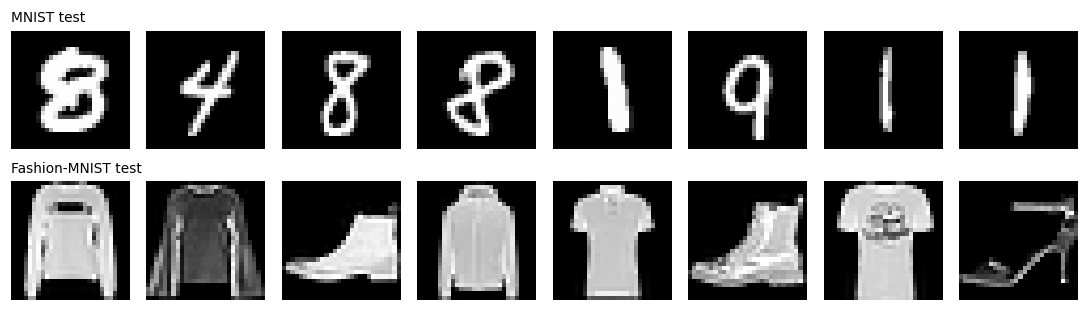

In [2]:
DATA_ROOT = str(root_dir / "data")

X_train, y_train, X_mnist, y_mnist, X_fmnist, y_fmnist = mc.load_datasets(
    DATA_ROOT, n_train=10000, n_test=2000, seed=SEED)

print(f"train: {X_train.shape}, MNIST test: {X_mnist.shape}, Fashion-MNIST test: {X_fmnist.shape}")

fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for i in range(8):
    axes[0, i].imshow(X_mnist[i, 0], cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(X_fmnist[i, 0], cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_title("MNIST test", loc="left", fontsize=9)
axes[1, 0].set_title("Fashion-MNIST test", loc="left", fontsize=9)
plt.tight_layout()
plt.show()

## Source model: MAP training + last-layer Laplace

`mc.SmallCNN` (two conv blocks + one FC layer, 128-d features) plays the role of the feature extractor `g`; the linear head `h` (128 -> 10) gets the Bayesian treatment via the same exact-Hessian `LastLayerLaplace.fit` used for the toy, with `tau_prior = weight_decay * N_train` (TODO.md Sec. 1b convention) -- unlike the synthetic toy, this needs **no** extra prior-scale correction; the CNN's features don't exhibit the same pathological ray-aligned overconfidence the toy's 2D MLP did (see `synthetic_track.ipynb`'s setup note), so the naive convention already gives a well-behaved posterior here.

In [3]:
model = mc.build_model(seed=SEED)
tau_prior = mc.train_map(model, X_train, y_train, weight_decay=1e-4, lr=1e-3, epochs=5, batch_size=128, seed=SEED)

with torch.no_grad():
    mnist_test_acc = (model(X_mnist).argmax(dim=1) == y_mnist).float().mean().item()
print(f"MNIST test accuracy: {mnist_test_acc:.4f}")

laplace = LastLayerLaplace.fit(model, X_train, y_train, tau_prior=tau_prior)
eigvals = torch.linalg.eigvalsh(laplace.cov)
print(f"Laplace posterior covariance: shape {tuple(laplace.cov.shape)}, "
      f"eigenvalue range [{eigvals.min():.2e}, {eigvals.max():.2e}] (>= 0 => valid covariance)")

  epoch 1/5  loss=1.0016  train_acc=0.7275
  epoch 2/5  loss=0.2569  train_acc=0.9220
  epoch 3/5  loss=0.1577  train_acc=0.9521
  epoch 4/5  loss=0.1130  train_acc=0.9646
  epoch 5/5  loss=0.0840  train_acc=0.9733
MNIST test accuracy: 0.9780
Laplace posterior covariance: shape (1290, 1290), eigenvalue range [-1.13e-05, 1.00e+00] (>= 0 => valid covariance)


## MNIST test vs. Fashion-MNIST test

BALD decomposition (`TODO.md` Sec. 7): `total_entropy = H[E_theta p(y|x,theta)]`, `aleatoric = E_theta[H[p(y|x,theta)]]`, `epistemic = total - aleatoric`. Also reports the plain MAP softmax entropy (no Bayesian treatment at all) as a baseline, to see how much the Laplace treatment adds on top of it.

In [4]:
gen = torch.Generator().manual_seed(SEED)
out_mnist = laplace.predictive(model, X_mnist, M=200, generator=gen)
gen = torch.Generator().manual_seed(SEED)
out_fmnist = laplace.predictive(model, X_fmnist, M=200, generator=gen)

map_ent_mnist = map_entropy(model, X_mnist)
map_ent_fmnist = map_entropy(model, X_fmnist)

print(f"{'':22s} {'MAP entropy':>14s} {'epistemic':>12s} {'aleatoric':>12s} {'total':>10s}")
for name, out, map_ent in [("MNIST test", out_mnist, map_ent_mnist), ("Fashion-MNIST test", out_fmnist, map_ent_fmnist)]:
    print(f"{name:22s} {map_ent.mean().item():14.4f} {out['epistemic'].mean().item():12.4f} "
          f"{out['aleatoric'].mean().item():12.4f} {out['total_entropy'].mean().item():10.4f}")

print(f"\nratio Fashion-MNIST / MNIST -- MAP entropy: {map_ent_fmnist.mean() / map_ent_mnist.mean():.2f}x   "
      f"epistemic: {out_fmnist['epistemic'].mean() / out_mnist['epistemic'].mean():.2f}x   "
      f"total: {out_fmnist['total_entropy'].mean() / out_mnist['total_entropy'].mean():.2f}x")

                          MAP entropy    epistemic    aleatoric      total
MNIST test                     0.1012       0.0498       0.1360     0.1857
Fashion-MNIST test             0.8760       0.5466       0.7875     1.3341

ratio Fashion-MNIST / MNIST -- MAP entropy: 8.65x   epistemic: 10.98x   total: 7.18x


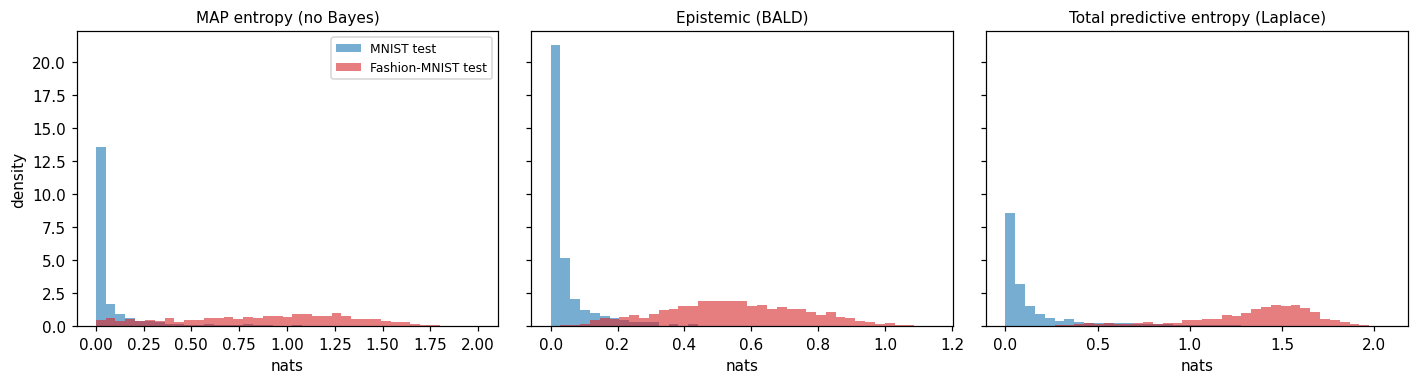

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
panels = [
    ("MAP entropy (no Bayes)", map_ent_mnist.numpy(), map_ent_fmnist.numpy()),
    ("Epistemic (BALD)", out_mnist["epistemic"].numpy(), out_fmnist["epistemic"].numpy()),
    ("Total predictive entropy (Laplace)", out_mnist["total_entropy"].numpy(), out_fmnist["total_entropy"].numpy()),
]
for ax, (title, mnist_vals, fmnist_vals) in zip(axes, panels):
    bins = np.linspace(0, max(mnist_vals.max(), fmnist_vals.max()), 40)
    ax.hist(mnist_vals, bins=bins, density=True, alpha=0.6, color="tab:blue", label="MNIST test")
    ax.hist(fmnist_vals, bins=bins, density=True, alpha=0.6, color="tab:red", label="Fashion-MNIST test")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("nats")
axes[0].set_ylabel("density")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

### OOD-detection quality (bonus, not required by the checklist item)

If the uncertainty signal is meaningful, it should also work as an OOD *detector*: label MNIST test = in-distribution (0), Fashion-MNIST test = OOD (1), and score each point by its uncertainty. AUROC quantifies how well each signal separates the two, independent of any threshold choice -- the same kind of metric `TODO.md` Sec. 8 uses for misclassification detection, applied here to distribution shift instead.

In [6]:
ood_labels = np.concatenate([np.zeros(len(y_mnist)), np.ones(len(y_fmnist))])

scores = {
    "MAP entropy (no Bayes)": np.concatenate([map_ent_mnist.numpy(), map_ent_fmnist.numpy()]),
    "Epistemic (BALD)": np.concatenate([out_mnist["epistemic"].numpy(), out_fmnist["epistemic"].numpy()]),
    "Total predictive entropy (Laplace)": np.concatenate([out_mnist["total_entropy"].numpy(), out_fmnist["total_entropy"].numpy()]),
}
for name, score in scores.items():
    print(f"AUROC ({name}): {roc_auc_score(ood_labels, score):.4f}")

AUROC (MAP entropy (no Bayes)): 0.9463
AUROC (Epistemic (BALD)): 0.9870
AUROC (Total predictive entropy (Laplace)): 0.9790


## Part 2 -- Rotated MNIST (optional)

Same trained model and Laplace posterior as Part 1 -- the source was trained only on upright digits, so rotation is a *controlled*, continuous distribution shift (unlike the qualitatively different Fashion-MNIST) with a known, orderable severity (the angle itself). Uncertainty is expected to rise as digits stop looking like anything seen in training, then partially recede as some rotations (notably near 180 degrees) make a digit resemble a different, still-plausible digit (e.g. a rotated 6 starting to look like a 9) rather than an unrecognizable shape -- so a non-monotonic curve peaking well before 180 degrees is expected, not a bug.

In [7]:
from torchvision.transforms import functional as TF

ANGLES = np.linspace(0, 180, 10)

rows = []
for i, angle in enumerate(ANGLES):
    X_rot = TF.rotate(X_mnist, float(angle))
    with torch.no_grad():
        acc = (model(X_rot).argmax(dim=1) == y_mnist).float().mean().item()
    out = laplace.predictive(model, X_rot, M=200, generator=torch.Generator().manual_seed(SEED + i))
    rows.append(dict(
        angle=float(angle), accuracy=acc,
        epistemic=out["epistemic"].mean().item(),
        aleatoric=out["aleatoric"].mean().item(),
        total=out["total_entropy"].mean().item(),
        map_entropy=map_entropy(model, X_rot).mean().item(),
    ))

print(f"{'angle':>6s} {'accuracy':>9s} {'epistemic':>10s} {'aleatoric':>10s} {'total':>8s} {'map_ent':>8s}")
for r in rows:
    print(f"{r['angle']:6.1f} {r['accuracy']:9.3f} {r['epistemic']:10.4f} {r['aleatoric']:10.4f} "
          f"{r['total']:8.4f} {r['map_entropy']:8.4f}")

 angle  accuracy  epistemic  aleatoric    total  map_ent
   0.0     0.978     0.0498     0.1360   0.1857   0.1012
  20.0     0.906     0.1100     0.3119   0.4219   0.2716
  40.0     0.585     0.2884     0.6553   0.9438   0.6584
  60.0     0.257     0.3804     0.7804   1.1607   0.8236
  80.0     0.162     0.4309     0.7680   1.1989   0.8048
 100.0     0.118     0.4423     0.7110   1.1533   0.7338
 120.0     0.119     0.3918     0.6900   1.0817   0.6930
 140.0     0.209     0.3469     0.6786   1.0255   0.6949
 160.0     0.289     0.2809     0.6023   0.8832   0.5968
 180.0     0.306     0.2573     0.5315   0.7888   0.5087


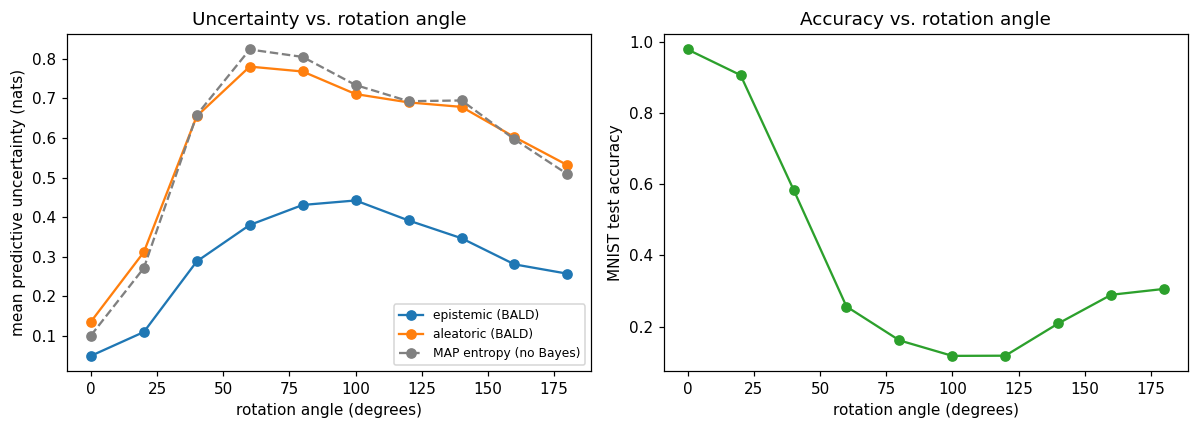

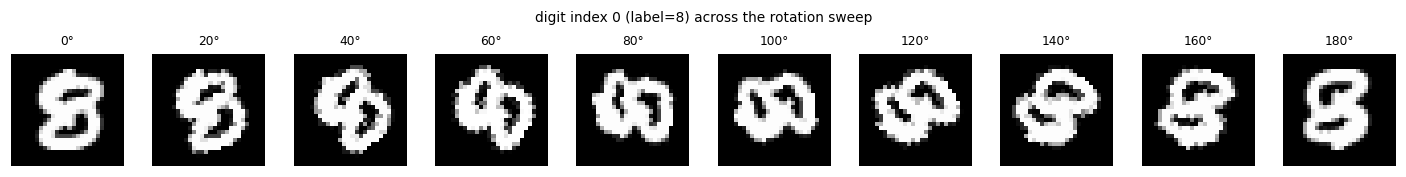

In [8]:
angles = [r["angle"] for r in rows]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(angles, [r["epistemic"] for r in rows], "o-", label="epistemic (BALD)")
axes[0].plot(angles, [r["aleatoric"] for r in rows], "o-", label="aleatoric (BALD)")
axes[0].plot(angles, [r["map_entropy"] for r in rows], "o--", color="gray", label="MAP entropy (no Bayes)")
axes[0].set_xlabel("rotation angle (degrees)")
axes[0].set_ylabel("mean predictive uncertainty (nats)")
axes[0].set_title("Uncertainty vs. rotation angle")
axes[0].legend(fontsize=8)

axes[1].plot(angles, [r["accuracy"] for r in rows], "o-", color="tab:green")
axes[1].set_xlabel("rotation angle (degrees)")
axes[1].set_ylabel("MNIST test accuracy")
axes[1].set_title("Accuracy vs. rotation angle")
fig.tight_layout()
plt.show()

# a few example digits across the sweep, for visual context
fig, axes = plt.subplots(1, len(ANGLES), figsize=(1.3 * len(ANGLES), 1.6))
example_idx = 0
for ax, angle in zip(axes, ANGLES):
    img = TF.rotate(X_mnist[example_idx:example_idx + 1], float(angle))[0, 0]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{angle:.0f}°", fontsize=8)
    ax.axis("off")
fig.suptitle(f"digit index {example_idx} (label={y_mnist[example_idx].item()}) across the rotation sweep", fontsize=9)
plt.tight_layout()
plt.show()